In [ ]:
import zipfile
import os

# Check current files in directory
print("Current files:", os.listdir())

# Extract the zip
with zipfile.ZipFile("archive (3).zip", 'r') as zip_ref:
    zip_ref.extractall("face-mask-dataset")

# Check contents
print("Extracted to:", os.listdir("face-mask-dataset"))


Current files: ['.config', 'archive (3).zip', 'sample_data']
Extracted to: ['data']


In [ ]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Paths
dataset_path = 'face-mask-dataset/data'
categories = ['with_mask', 'without_mask']
img_size = 100

# Load images and labels
data = []
labels = []

for category in categories:
    folder_path = os.path.join(dataset_path, category)
    label = categories.index(category)
    for img_name in os.listdir(folder_path):
        try:
            img_path = os.path.join(folder_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.resize(img, (img_size, img_size))
            data.append(img)
            labels.append(label)
        except:
            pass

# Convert to arrays
X = np.array(data) / 255.0  # Normalize
y = to_categorical(labels)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")


Training samples: 6042, Test samples: 1511


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(2, activation='softmax')  # 2 classes
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train
model.fit(X_train, y_train, epochs=10, validation_split=0.1, batch_size=32)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 87s 485ms/step - accuracy: 0.7396 - loss: 0.5235 - val_accuracy: 0.9025 - val_loss: 0.2534
Epoch 2/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 139s 472ms/step - accuracy: 0.8954 - loss: 0.2579 - val_accuracy: 0.9091 - val_loss: 0.2579
Epoch 3/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 80s 473ms/step - accuracy: 0.9197 - loss: 0.2038 - val_accuracy: 0.9157 - val_loss: 0.2308
Epoch 4/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 79s 464ms/step - accuracy: 0.9308 - loss: 0.1748 - val_accuracy: 0.9107 - val_loss: 0.2216
Epoch 5/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 82s 467ms/step - accuracy: 0.9523 - loss: 0.1277 - val_accuracy: 0.9322 - val_loss: 0.1955
Epoch 6/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 81s 474ms/step - accuracy: 0.9638 - loss: 0.0942 - val_accuracy: 0.9388 - val_loss: 0.2064
Epoch 7/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 81s 470ms/step - accuracy: 0.9781 - loss: 0.0618 - val_accuracy: 0.9372 - val_loss: 0.2001
Epoch 8/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 80s 461ms/step - accuracy: 0.9778 - loss: 

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")


48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - accuracy: 0.9454 - loss: 0.2299
Test Accuracy: 94.31%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Prediction: without_mask


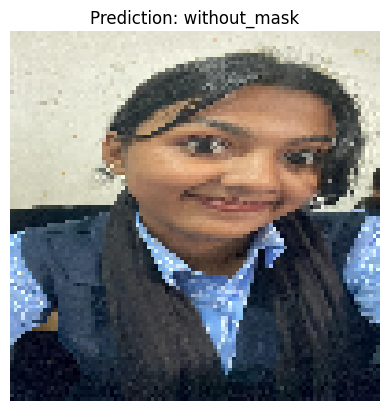

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = '/content/aysha.jpg'  # replace with your actual filename

# Load and preprocess image
img = image.load_img(img_path, target_size=(100, 100))  # same size used during training
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

# Predict
prediction = model.predict(img_array)
class_index = np.argmax(prediction)
label = ['without_mask', 'with_mask'][class_index]

print(f"Prediction: {label}")

# Show the image
plt.imshow(img)
plt.title(f"Prediction: {label}")
plt.axis('off')
plt.show()


In [6]:
readme = """
# Face Mask Detection Using Deep Learning

## Overview
This project uses a Convolutional Neural Network (CNN) to detect whether a person is wearing a face mask or not.
"""

with open("README.md", "w") as f:
    f.write(readme)

requirements = """
tensorflow
keras
opencv-python
numpy
matplotlib
scikit-learn
jupyter
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("Files created successfully!")

Files created successfully!


In [7]:
!ls

README.md  requirements.txt  sample_data


In [8]:
!ls

README.md  requirements.txt  sample_data
